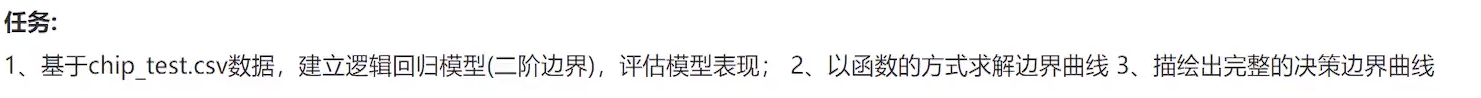

In [1]:
# load data
import pandas as pd
import numpy as np
data = pd.read_csv("chip_test.csv")
data.head()

,test1,test2,pass
0,0.051267,0.69956,1
1,-0.092742,0.68494,1
2,-0.213710,0.69225,1
3,-0.375000,0.50219,1
4,0.183760,0.93348,0


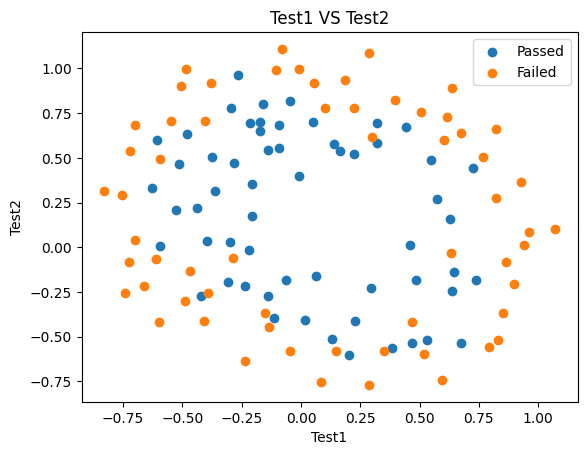

In [5]:
# visualized data
import matplotlib.pyplot as plt
fig = plt.figure()

mask = data.loc[:,'pass'] == 1
# 标记成功的数据点
passed = plt.scatter(data.loc[:,'test1'][mask], data.loc[:,'test2'][mask])
# 标记失败的数据点
failed = plt.scatter(data.loc[:,'test1'][~mask], data.loc[:,'test2'][~mask])
plt.title('Test1 VS Test2')
plt.xlabel('Test1')
plt.ylabel('Test2')
# 添加图例
plt.legend((passed, failed), ('Passed', 'Failed'))
plt.show()

In [6]:
# define data
X1 = data.loc[:,'test1']
X2 = data.loc[:,'test2']
y = data.loc[:,'pass']
# generate data
X1_2 = X1 * X1
X2_2 = X2 * X2
X1_X2 = X1 * X2

X_new = pd.DataFrame({'X1':X1,"X2":X2,"X1_2":X1_2,"X2_2":X2_2,"X1_X2":X1_X2})
X_new.head()


,X1,X2,X1_2,X2_2,X1_X2
0,0.051267,0.69956,0.002628,0.489384,0.035864
1,-0.092742,0.68494,0.008601,0.469143,-0.063523
2,-0.213710,0.69225,0.045672,0.479210,-0.147941
3,-0.375000,0.50219,0.140625,0.252195,-0.188321
4,0.183760,0.93348,0.033768,0.871385,0.171536


In [8]:
#establish the model and train it
from sklearn.linear_model import LogisticRegression
LogicR = LogisticRegression()
LogicR.fit(X_new.values, y.values)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [9]:
# 预测y值，与原数据比较
from sklearn.metrics import accuracy_score
y_predict = LogicR.predict(X_new.values)
y_accuracy = accuracy_score(y,y_predict)
print(y_accuracy)


0.8135593220338984


In [11]:
# 提取模型中的参数
theta0 = LogicR.intercept_
theta1,theta2,theta3,theta4,theta5 = LogicR.coef_[0][0],LogicR.coef_[0][1],LogicR.coef_[0][2],LogicR.coef_[0][3],LogicR.coef_[0][4]

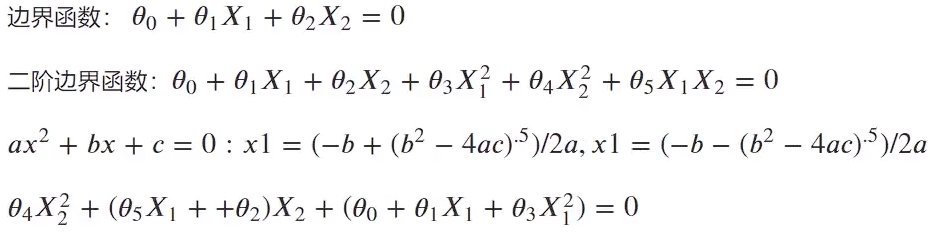

D:\study\code\python\study\DailyWork\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


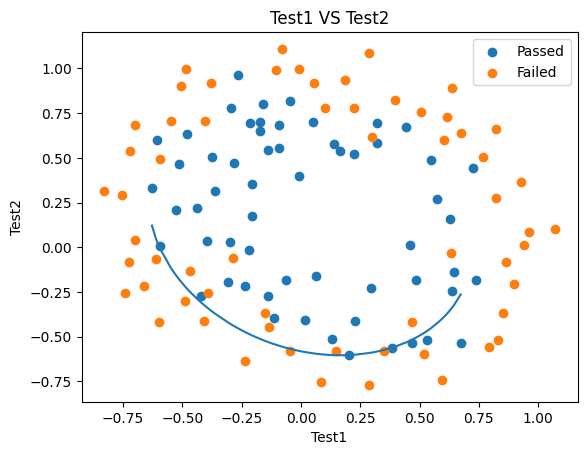

In [15]:
# 对X1的值进行大小排序，这样画出来的边界曲线才是一条光滑的曲线
X1_new  = X1.sort_values()
a = theta4
b = theta5 * X1_new + theta2
c = theta0 + theta1 * X1_new + theta3 * X1_new * X1_new
# 求解每一个X1点对应的决策边界上的X2的新值，也就是画出决策边界线
# 该曲线只考虑了一半的情况，所以曲线只有下半部分
X2_new_boundary = (-b + np.sqrt(b * b - 4 * a * c))/(2 * a)

# 画出决策边界
fig2 = plt.figure()
plt.plot(X1_new,X2_new_boundary)
passed = plt.scatter(data.loc[:,'test1'][mask], data.loc[:,'test2'][mask])
# 标记失败的数据点
failed = plt.scatter(data.loc[:,'test1'][~mask], data.loc[:,'test2'][~mask])
plt.title('Test1 VS Test2')
plt.xlabel('Test1')
plt.ylabel('Test2')
# 添加图例
plt.legend((passed, failed), ('Passed', 'Failed'))
plt.show()

In [27]:
# 定义函数，计算边界曲线
def f(x):
    a = theta4
    b = theta5 * x + theta2
    c = theta0 + theta1 * x + theta3 * x * x
    # 曲线的上下两部分
    X2_new_boundary_down = (-b + np.sqrt(b * b - 4 * a * c))/(2 * a)
    X2_new_boundary_top = (-b - np.sqrt(b * b - 4 * a * c))/(2 * a)
    return X2_new_boundary_top,X2_new_boundary_down

In [28]:
X2_new_boundary_top = []
X2_new_boundary_down = []
for x in X1_new:
    X2_new_boundary_top.append(f(x)[0])
    X2_new_boundary_down.append(f(x)[1])

print(X2_new_boundary_down)
print(X2_new_boundary_top)

[array([nan]), array([nan]), array([nan]), array([nan]), array([nan]), array([nan]), array([nan]), array([nan]), array([0.12118557]), array([0.046756]), array([0.02694692]), array([0.00869419]), array([-0.00832964]), array([-0.00832964]), array([-0.11719503]), array([-0.16040596]), array([-0.18016739]), array([-0.18965406]), array([-0.21670972]), array([-0.22529994]), array([-0.23369318]), array([-0.24992385]), array([-0.28761169]), array([-0.30846342]), array([-0.32171357]), array([-0.32815515]), array([-0.3344791]), array([-0.34068868]), array([-0.35277682]), array([-0.35866103]), array([-0.37012269]), array([-0.42185219]), array([-0.42655662]), array([-0.43118989]), array([-0.43573725]), array([-0.44020804]), array([-0.45317261]), array([-0.4733505]), array([-0.4733505]), array([-0.48464004]), array([-0.48827191]), array([-0.49183935]), array([-0.49183935]), array([-0.51192772]), array([-0.51192772]), array([-0.51813664]), array([-0.52410902]), array([-0.52985346]), array([-0.529853

C:\Users\LianYing_T\AppData\Local\Temp\ipykernel_34544\4087613013.py:7: RuntimeWarning: invalid value encountered in sqrt
  X2_new_boundary_down = (-b + np.sqrt(b * b - 4 * a * c))/(2 * a)
C:\Users\LianYing_T\AppData\Local\Temp\ipykernel_34544\4087613013.py:8: RuntimeWarning: invalid value encountered in sqrt
  X2_new_boundary_top = (-b - np.sqrt(b * b - 4 * a * c))/(2 * a)


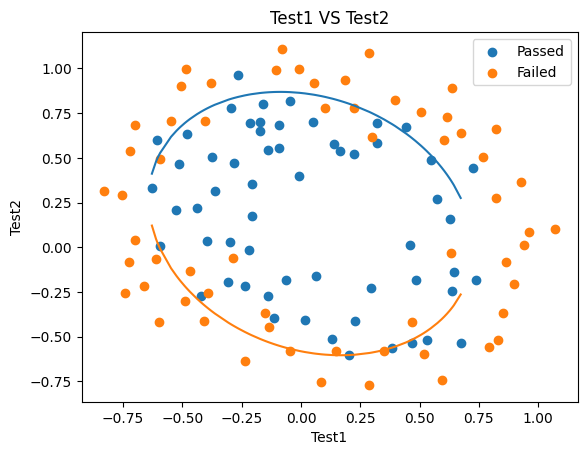

In [30]:
fig3 = plt.figure()
passed = plt.scatter(data.loc[:,'test1'][mask], data.loc[:,'test2'][mask])
# 标记失败的数据点
failed = plt.scatter(data.loc[:,'test1'][~mask], data.loc[:,'test2'][~mask])
plt.plot(X1_new,X2_new_boundary_top)
plt.plot(X1_new,X2_new_boundary_down)
plt.title('Test1 VS Test2')
plt.xlabel('Test1')
plt.ylabel('Test2')
# 添加图例
plt.legend((passed, failed), ('Passed', 'Failed'))
plt.show()

In [31]:
# 因X1的点的分布可能是不均匀的，所以其边界曲线是有可能无法接上的，所以，要生均匀分布的X1点，再进行边界曲线的绘制
X1_range = [-0.9 + x/10000 for x in range(0,19000)]
X1_range = np.array(X1_range)
X2_new_boundary_top1 = []
X2_new_boundary_down1 = []
for x in X1_range:
    X2_new_boundary_top1.append(f(x)[0])
    X2_new_boundary_down1.append(f(x)[1])

C:\Users\LianYing_T\AppData\Local\Temp\ipykernel_34544\4087613013.py:7: RuntimeWarning: invalid value encountered in sqrt
  X2_new_boundary_down = (-b + np.sqrt(b * b - 4 * a * c))/(2 * a)
C:\Users\LianYing_T\AppData\Local\Temp\ipykernel_34544\4087613013.py:8: RuntimeWarning: invalid value encountered in sqrt
  X2_new_boundary_top = (-b - np.sqrt(b * b - 4 * a * c))/(2 * a)


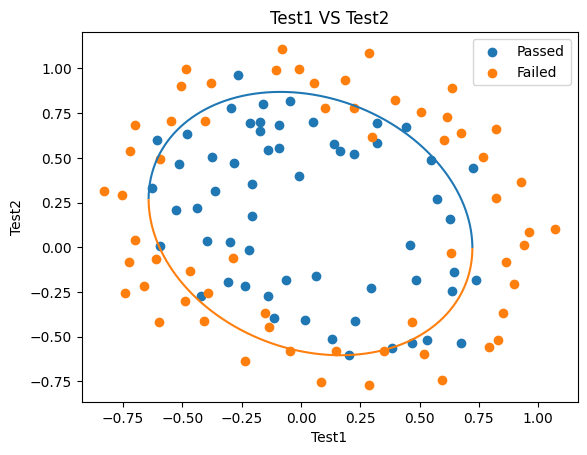

In [32]:
fig3 = plt.figure()
passed = plt.scatter(data.loc[:,'test1'][mask], data.loc[:,'test2'][mask])
# 标记失败的数据点
failed = plt.scatter(data.loc[:,'test1'][~mask], data.loc[:,'test2'][~mask])
plt.plot(X1_range,X2_new_boundary_top1)
plt.plot(X1_range,X2_new_boundary_down1)
plt.title('Test1 VS Test2')
plt.xlabel('Test1')
plt.ylabel('Test2')
# 添加图例
plt.legend((passed, failed), ('Passed', 'Failed'))
plt.show()